In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("Libraries imported successfully!")

Libraries imported successfully!


In [2]:
import random

np.random.seed(42)

n = 600

dates = pd.date_range(start="2023-01-01", end="2025-12-31", periods=n)

vehicle_types = ["SUV", "Sedan", "Hatchback", "Truck", "Electric"]
brands = ["Toyota", "Hyundai", "Tata", "Honda", "Mahindra", "Maruti"]
regions = ["North", "South", "East", "West", "Central"]
fuel_types = ["Petrol", "Diesel", "Electric", "Hybrid"]
age_groups = ["18-25", "26-35", "36-45", "46-55", "56+"]

data = {
    "Date": dates,
    "Vehicle_Type": np.random.choice(vehicle_types, n),
    "Brand": np.random.choice(brands, n),
    "Region": np.random.choice(regions, n),
    "Fuel_Type": np.random.choice(fuel_types, n),
    "Price": np.random.randint(500000, 4000000, n),
    "Units_Sold": np.random.randint(10, 500, n),
    "Customer_Rating": np.round(np.random.uniform(2.5, 5.0, n), 1),
    "Age_Group": np.random.choice(age_groups, n)
}

df = pd.DataFrame(data)

print("Dataset created successfully!")
print("Number of records:", len(df))

Dataset created successfully!
Number of records: 600


In [3]:
df.head()

,Date,Vehicle_Type,Brand,Region,Fuel_Type,Price,Units_Sold,Customer_Rating,Age_Group
0,2023-01-01 00:00:00.000000000,Truck,Tata,North,Petrol,1771300,229,3.6,36-45
1,2023-01-02 19:52:23.238731218,Electric,Honda,Central,Diesel,1544327,400,4.8,46-55
2,2023-01-04 15:44:46.477462437,Hatchback,Mahindra,East,Electric,693783,172,2.9,18-25
3,2023-01-06 11:37:09.716193656,Electric,Honda,South,Electric,2615904,448,3.5,56+
4,2023-01-08 07:29:32.954924874,Electric,Tata,South,Petrol,1515416,229,4.3,56+


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 600 entries, 0 to 599
Data columns (total 9 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   Date             600 non-null    datetime64[ns]
 1   Vehicle_Type     600 non-null    object        
 2   Brand            600 non-null    object        
 3   Region           600 non-null    object        
 4   Fuel_Type        600 non-null    object        
 5   Price            600 non-null    int64         
 6   Units_Sold       600 non-null    int64         
 7   Customer_Rating  600 non-null    float64       
 8   Age_Group        600 non-null    object        
dtypes: datetime64[ns](1), float64(1), int64(2), object(5)
memory usage: 42.3+ KB


In [5]:
df.isnull().sum()

,0
Date,0
Vehicle_Type,0
Brand,0
Region,0
Fuel_Type,0
Price,0
Units_Sold,0
Customer_Rating,0
Age_Group,0


In [6]:
df.isnull().sum().sum()

np.int64(0)

In [7]:
# Fill missing numerical values with the median
df["Price"] = df["Price"].fillna(df["Price"].median())
df["Units_Sold"] = df["Units_Sold"].fillna(df["Units_Sold"].median())
df["Customer_Rating"] = df["Customer_Rating"].fillna(df["Customer_Rating"].median())

# Fill missing categorical values with the mode
df["Fuel_Type"] = df["Fuel_Type"].fillna(df["Fuel_Type"].mode()[0])
df["Region"] = df["Region"].fillna(df["Region"].mode()[0])

print("Missing values handled successfully!")

Missing values handled successfully!


In [8]:
df.isnull().sum()

,0
Date,0
Vehicle_Type,0
Brand,0
Region,0
Fuel_Type,0
Price,0
Units_Sold,0
Customer_Rating,0
Age_Group,0


In [9]:
# Detect outliers using the IQR method

columns = ["Price", "Units_Sold", "Customer_Rating"]

for col in columns:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower_limit = Q1 - 1.5 * IQR
    upper_limit = Q3 + 1.5 * IQR

    outliers = df[(df[col] < lower_limit) | (df[col] > upper_limit)]

    print(f"{col}: {len(outliers)} outliers found")

Price: 0 outliers found
Units_Sold: 0 outliers found
Customer_Rating: 0 outliers found


In [10]:
# Handle outliers using IQR capping

columns = ["Price", "Units_Sold", "Customer_Rating"]

for col in columns:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower_limit = Q1 - 1.5 * IQR
    upper_limit = Q3 + 1.5 * IQR

    df[col] = df[col].clip(lower=lower_limit, upper=upper_limit)

print("Outliers handled successfully!")

Outliers handled successfully!


In [11]:
df.describe()

,Date,Price,Units_Sold,Customer_Rating
count,600,6.000000e+02,600.000000,600.000000
mean,2024-07-01 12:00:00,2.279318e+06,259.110000,3.796333
min,2023-01-01 00:00:00,5.079670e+05,10.000000,2.500000
25%,2023-10-01 18:00:00,1.512355e+06,137.750000,3.200000
50%,2024-07-01 12:00:00,2.228101e+06,264.000000,3.800000
75%,2025-04-01 06:00:00,3.128528e+06,385.250000,4.400000
max,2025-12-31 00:00:00,3.984144e+06,499.000000,5.000000
std,NaN,9.693219e+05,141.237287,0.727623


In [12]:
# Statistical summary

print("Statistical Summary:")
print(df[["Price", "Units_Sold", "Customer_Rating"]].describe())

Statistical Summary:
              Price  Units_Sold  Customer_Rating
count  6.000000e+02  600.000000       600.000000
mean   2.279318e+06  259.110000         3.796333
std    9.693219e+05  141.237287         0.727623
min    5.079670e+05   10.000000         2.500000
25%    1.512355e+06  137.750000         3.200000
50%    2.228101e+06  264.000000         3.800000
75%    3.128528e+06  385.250000         4.400000
max    3.984144e+06  499.000000         5.000000


In [13]:
print("Average Units Sold:", round(df["Units_Sold"].mean(), 2))
print("Average Vehicle Price:", round(df["Price"].mean(), 2))
print("Average Customer Rating:", round(df["Customer_Rating"].mean(), 2))

Average Units Sold: 259.11
Average Vehicle Price: 2279317.85
Average Customer Rating: 3.8


In [14]:
brand_sales = df.groupby("Brand")["Units_Sold"].sum().sort_values(ascending=False)

print("Total Units Sold by Brand:")
print(brand_sales)

Total Units Sold by Brand:
Brand
Toyota      29181
Maruti      28181
Tata        26412
Mahindra    24560
Honda       24271
Hyundai     22861
Name: Units_Sold, dtype: int64


In [15]:
region_sales = df.groupby("Region")["Units_Sold"].sum().sort_values(ascending=False)

print("Total Units Sold by Region:")
print(region_sales)

Total Units Sold by Region:
Region
South      35919
East       33598
North      29704
West       28166
Central    28079
Name: Units_Sold, dtype: int64


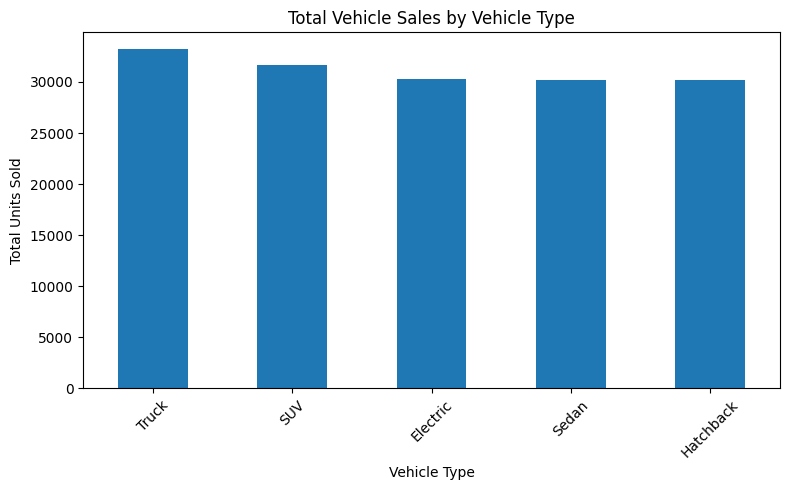

In [16]:
plt.figure(figsize=(8,5))

vehicle_sales = df.groupby("Vehicle_Type")["Units_Sold"].sum().sort_values(ascending=False)

vehicle_sales.plot(kind="bar")

plt.title("Total Vehicle Sales by Vehicle Type")
plt.xlabel("Vehicle Type")
plt.ylabel("Total Units Sold")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

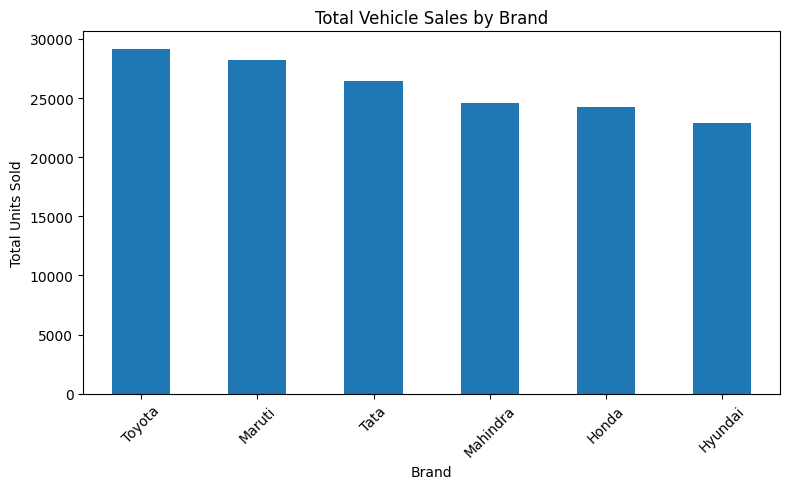

In [17]:
plt.figure(figsize=(8,5))

brand_sales.plot(kind="bar")

plt.title("Total Vehicle Sales by Brand")
plt.xlabel("Brand")
plt.ylabel("Total Units Sold")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

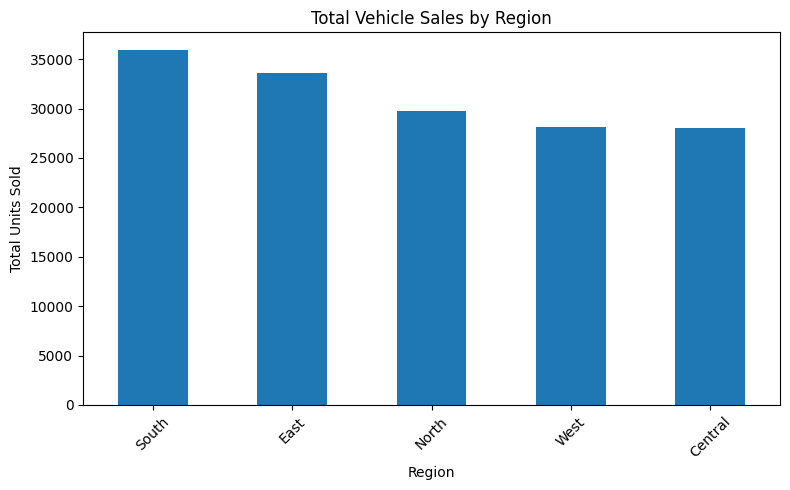

In [18]:
plt.figure(figsize=(8,5))

region_sales.plot(kind="bar")

plt.title("Total Vehicle Sales by Region")
plt.xlabel("Region")
plt.ylabel("Total Units Sold")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

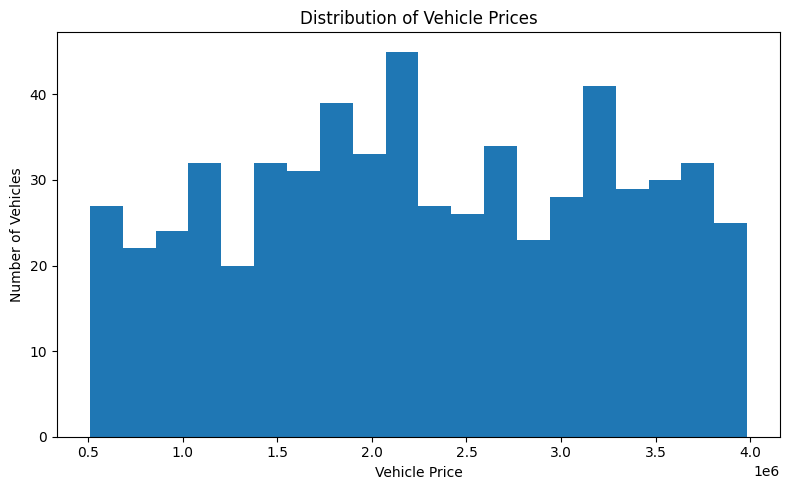

In [19]:
plt.figure(figsize=(8,5))

plt.hist(df["Price"], bins=20)

plt.title("Distribution of Vehicle Prices")
plt.xlabel("Vehicle Price")
plt.ylabel("Number of Vehicles")

plt.tight_layout()
plt.show()

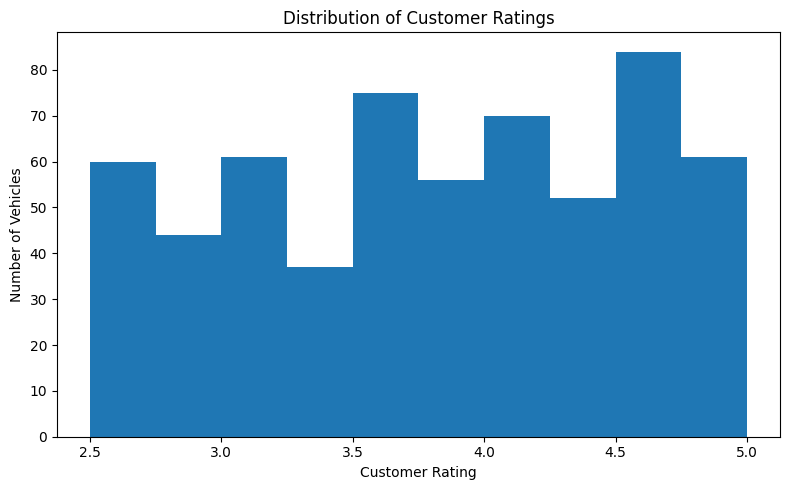

In [20]:
plt.figure(figsize=(8,5))

plt.hist(df["Customer_Rating"], bins=10)

plt.title("Distribution of Customer Ratings")
plt.xlabel("Customer Rating")
plt.ylabel("Number of Vehicles")

plt.tight_layout()
plt.show()

In [21]:
print("KEY INSIGHTS")
print("-" * 40)

print("Top Vehicle Type:", vehicle_sales.idxmax())
print("Highest Selling Brand:", brand_sales.idxmax())
print("Highest Selling Region:", region_sales.idxmax())

print("Average Vehicle Price:", round(df["Price"].mean(), 2))
print("Average Units Sold:", round(df["Units_Sold"].mean(), 2))
print("Average Customer Rating:", round(df["Customer_Rating"].mean(), 2))

KEY INSIGHTS
----------------------------------------
Top Vehicle Type: Truck
Highest Selling Brand: Toyota
Highest Selling Region: South
Average Vehicle Price: 2279317.85
Average Units Sold: 259.11
Average Customer Rating: 3.8


In [22]:
print("\nVehicle Type Sales:")
print(vehicle_sales)

print("\nBrand Sales:")
print(brand_sales)

print("\nRegion Sales:")
print(region_sales)


Vehicle Type Sales:
Vehicle_Type
Truck        33202
SUV          31631
Electric     30250
Sedan        30235
Hatchback    30148
Name: Units_Sold, dtype: int64

Brand Sales:
Brand
Toyota      29181
Maruti      28181
Tata        26412
Mahindra    24560
Honda       24271
Hyundai     22861
Name: Units_Sold, dtype: int64

Region Sales:
Region
South      35919
East       33598
North      29704
West       28166
Central    28079
Name: Units_Sold, dtype: int64


In [24]:
# Save the cleaned dataset as a CSV file

df.to_csv("automotive_cleaned_dataset.csv", index=False)

print("Dataset saved successfully!")

Dataset saved successfully!
